In [1]:
import pandas as pd


In [2]:
df = pd.read_csv('../data/KV-traces-2026.zst', compression='zstd')
# To save as a standard CSV:
df.to_csv('../data/kv-traces-2026.csv', index=False)

In [8]:
file_path = '../data/kv-traces-2026.csv'
df = pd.read_csv(file_path)

In [4]:
print("First 10 rows:")
print(df.head(10))

print("\nColumn names:")
print(df.columns)

print("\nDataset shape (rows, columns):")
print(df.shape)
print("\nData types of each column:")
print(df.dtypes)

First 10 rows:
          key   op  size  op_count  key_size
0  1668757755  SET    82         1        40
1  1668757755  GET     0         1        40
2  1668757805  SET   208         1        63
3  1668757805  GET     0         1        63
4  1665498006  GET   104         2        64
5  1666258101  GET    81         2        23
6  1665497896  GET   169        18        78
7  1665702915  SET   109         1        40
8  1665702915  GET     0         1        40
9  1665497896  GET   169        18        78

Column names:
Index(['key', 'op', 'size', 'op_count', 'key_size'], dtype='str')

Dataset shape (rows, columns):
(207409712, 5)

Data types of each column:
key         int64
op            str
size        int64
op_count    int64
key_size    int64
dtype: object


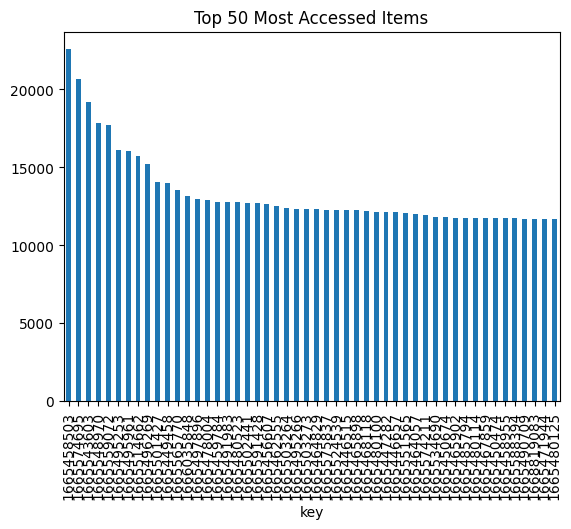

In [5]:
import matplotlib.pyplot as plt
key_col = df.columns[0] 
df[key_col].value_counts().head(50).plot(kind='bar')
plt.title("Top 50 Most Accessed Items")
plt.show()

Sampling dataset

In [10]:
df = pd.read_csv(file_path, nrows=200000)

print(df.head())
print(df.shape)

          key   op  size  op_count  key_size
0  1668757755  SET    82         1        40
1  1668757755  GET     0         1        40
2  1668757805  SET   208         1        63
3  1668757805  GET     0         1        63
4  1665498006  GET   104         2        64
(200000, 5)


Encoding and labelling

In [11]:
df['op'] = df['op'].map({'GET': 0, 'SET': 1})
last_seen = {}
recency = []

for i, key in enumerate(df['key']):
    if key in last_seen:
        recency.append(i - last_seen[key])
    else:
        recency.append(-1)
    last_seen[key] = i

df['recency'] = recency
#frequency computation
freq = {}
frequency = []

for key in df['key']:
    freq[key] = freq.get(key, 0) + 1
    frequency.append(freq[key])

df['frequency'] = frequency

 # creating label
K = 50  # lookahead window

labels = []

keys = df['key'].tolist()

for i in range(len(keys)):
    future_window = keys[i+1:i+K+1]
    if keys[i] in future_window:
        labels.append(1)
    else:
        labels.append(0)

df['label'] = labels

In [12]:
print(df.head())
print(df['label'].value_counts())

          key   op  size  op_count  key_size  recency  frequency  label
0  1668757755  1.0    82         1        40       -1          1      1
1  1668757755  0.0     0         1        40        1          2      0
2  1668757805  1.0   208         1        63       -1          1      1
3  1668757805  0.0     0         1        63        1          2      0
4  1665498006  0.0   104         2        64       -1          1      1
label
0    151678
1     48322
Name: count, dtype: int64


BASELINE ML MODEL FOR COMPARISON

In [40]:
# feature selection
features = ['recency', 'frequency', 'op', 'size', 'key_size']
X = df[features].copy()
y = df['label']

X['recency'] = X['recency'].replace(-1, X['recency'].max())

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# Fit imputer on train data only, then transform both sets
imputer = SimpleImputer(strategy='median')
X_train = pd.DataFrame(
    imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index
)
X_test = pd.DataFrame(
    imputer.transform(X_test), columns=X_test.columns, index=X_test.index
)

print('Missing values after preprocessing:', int(X_train.isna().sum().sum() + X_test.isna().sum().sum()))

Missing values after preprocessing: 0


In [41]:
# training
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, average_precision_score, classification_report, confusion_matrix, precision_recall_curve

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_fit_scaled, X_val_scaled, y_fit, y_val = train_test_split(
    X_train_scaled, y_train, test_size=0.2, shuffle=False
)

from sklearn.linear_model import SGDClassifier

model = SGDClassifier(loss='log_loss', class_weight='balanced', random_state=42)
model.fit(X_fit_scaled, y_fit)

val_prob = model.predict_proba(X_val_scaled)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, val_prob)
beta = 2.0
f_scores = (1 + beta**2) * precision[:-1] * recall[:-1] / ((beta**2 * precision[:-1]) + recall[:-1] + 1e-12)
best_idx = f_scores.argmax()
threshold = thresholds[best_idx]

print('Chosen threshold:', threshold)
print('Validation PR-AUC:', average_precision_score(y_val, val_prob))

Chosen threshold: 0.44965804089449257
Validation PR-AUC: 0.6354610348213722


In [42]:
# preds
y_prob = model.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_prob > threshold).astype(int)

#metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("PR-AUC:", average_precision_score(y_test, y_prob))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.868175
PR-AUC: 0.6582244623214044
Confusion matrix:
 [[27970  2319]
 [ 2954  6757]]
              precision    recall  f1-score   support

           0       0.90      0.92      0.91     30289
           1       0.74      0.70      0.72      9711

    accuracy                           0.87     40000
   macro avg       0.82      0.81      0.82     40000
weighted avg       0.87      0.87      0.87     40000



In [43]:
# threshold sensitivity for the cache tradeoff
import numpy as np
threshold_grid = np.linspace(0.1, 0.9, 17)

rows = []
for candidate_threshold in threshold_grid:
    candidate_pred = (val_prob > candidate_threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, candidate_pred).ravel()
    candidate_precision = tp / (tp + fp + 1e-12)
    candidate_recall = tp / (tp + fn + 1e-12)
    candidate_f1 = 2 * candidate_precision * candidate_recall / (candidate_precision + candidate_recall + 1e-12)
    beta = 2.0
    candidate_f2 = (1 + beta**2) * candidate_precision * candidate_recall / ((beta**2 * candidate_precision) + candidate_recall + 1e-12)
    rows.append({
        'threshold': candidate_threshold,
        'precision': candidate_precision,
        'recall': candidate_recall,
        'f1': candidate_f1,
        'f2': candidate_f2,
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'tn': tn,
    })

threshold_summary = pd.DataFrame(rows)
false_negative_cost = 2.0
false_positive_cost = 1.0
threshold_summary['utility'] = threshold_summary['tp'] - false_positive_cost * threshold_summary['fp'] - false_negative_cost * threshold_summary['fn']
best_utility_row = threshold_summary.loc[threshold_summary['utility'].idxmax()]

print('Top thresholds by F2 on validation:')
print(threshold_summary.sort_values(by='f2', ascending=False).head(8).round(4))
print()
print('Best threshold by cache-style utility (miss cost =', false_negative_cost, ', false alarm cost =', false_positive_cost, '):')
print(best_utility_row.round(4))

Top thresholds by F2 on validation:
    threshold  precision  recall      f1      f2    tp    fp    fn     tn  \
7        0.45     0.7942  0.6660  0.7245  0.6882  5215  1351  2615  22819   
8        0.50     0.8275  0.6542  0.7307  0.6828  5122  1068  2708  23102   
6        0.40     0.7104  0.6756  0.6926  0.6823  5290  2156  2540  22014   
5        0.35     0.6004  0.7042  0.6482  0.6807  5514  3670  2316  20500   
9        0.55     0.8426  0.6466  0.7317  0.6782  5063   946  2767  23224   
10       0.60     0.8504  0.6424  0.7319  0.6754  5030   885  2800  23285   
16       0.90     0.8601  0.6405  0.7342  0.6749  5015   816  2815  23354   
15       0.85     0.8598  0.6405  0.7341  0.6749  5015   818  2815  23352   

    utility  
7   -1366.0  
8   -1362.0  
6   -1946.0  
5   -2788.0  
9   -1417.0  
10  -1455.0  
16  -1431.0  
15  -1433.0  

Best threshold by cache-style utility (miss cost = 2.0 , false alarm cost = 1.0 ):
threshold        0.5000
precision        0.8275
recall      

In [31]:
# probability output for further comparison
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [32]:
# feature importace

importance = pd.DataFrame({
    'feature': features,
    'weight': model.coef_[0]
})

print(importance.sort_values(by='weight', ascending=False))

     feature    weight
2         op  1.470419
3       size  0.240381
1  frequency  0.145652
4   key_size  0.027824
0    recency -0.027411
